In [1]:
## Imports required components and manually creates a complex global path for debugging
import numpy as np

global_path = [
    [2.5 ,1, 0],
    [3, 1.5, 0.5*np.pi],
    [2.5, 2, np.pi],
    [1.5, 2, np.pi],
    [1, 1.5, 1.5*np.pi],
    [1, 0.5, 1.5*np.pi],
    [0.5, 0, np.pi],
    [0, 0, np.pi],
]

current_goal_ID = 1

print(f"Current goalpose for debugging: {global_path[current_goal_ID]}")

Current goalpose for debugging: [3, 1.5, 1.5707963267948966]


In [2]:
## Initialises a ROS node and required transform buffer objects for robot localisation
import rclpy
import tf2_ros

from rclpy.node import Node
from scipy.spatial.transform import Rotation as R

try:
    rclpy.init(args=None)
except: pass

try:
    node
except NameError:
    node = Node("local_planner") # <- If not already initialised, create your node here

tfBuffer = tf2_ros.Buffer()
listener = tf2_ros.TransformListener(tfBuffer, node, spin_thread=True)

In [3]:
def localiseRobot():
    """Localises the robot towards the 'map' coordinate frame. Returns pose in format (x,y,theta)"""
    while True:
        try:
            trans = tfBuffer.lookup_transform('map', 'base_link', rclpy.time.Time(), timeout=rclpy.duration.Duration(seconds=1.0))
            break
        except (tf2_ros.LookupException, tf2_ros.ConnectivityException, tf2_ros.ExtrapolationException):
            print("Robot localisation took longer than 1 sec")
            continue

    theta = R.from_quat([
        trans.transform.rotation.x,
        trans.transform.rotation.y,
        trans.transform.rotation.z,
        trans.transform.rotation.w]).as_euler("xyz")[2]
    
    return np.array([
        trans.transform.translation.x,
        trans.transform.translation.y,
        theta])

In [4]:
robotpose = localiseRobot()
print(robotpose)

[ 2.1560231   3.07528255 -0.43649196]


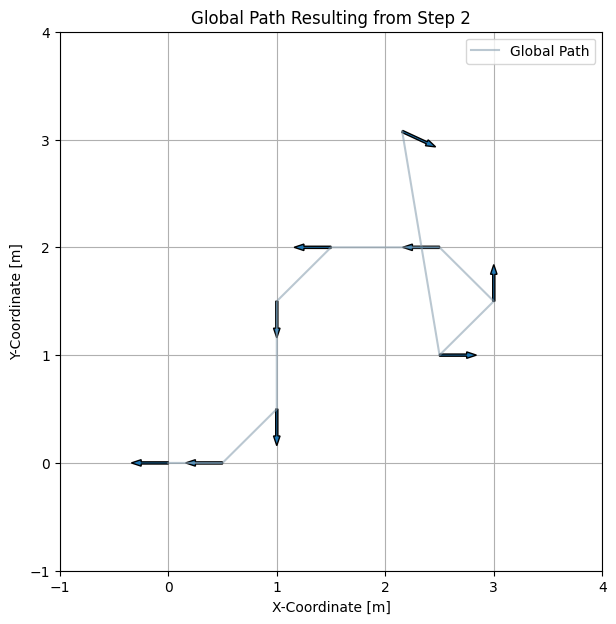

In [5]:
## Visualises global path and poses along the path in the transformed map
import matplotlib.pyplot as plt

# Store colours matching UAS TW colour scheme as dict 
colourScheme = {
    "darkblue": "#143049",
    "twblue": "#00649C",
    "lightblue": "#8DA3B3",
    "lightgrey": "#CBC0D5",
    "twgrey": "#72777A"
}

## Visualise transformed goal and robot poses
# Create single figure
plt.rcParams['figure.figsize'] = [7, 7]
fig, ax = plt.subplots()

positions_on_path = np.array([robotpose.tolist()] + global_path)[:,:2]
ax.plot(positions_on_path[:,0], positions_on_path[:,1], c=colourScheme["lightblue"], alpha=0.6, label="Global Path")

# Plot robot poses as arrows to indicate orientation
for s in [robotpose.tolist()] + global_path:
    # Calculate arrow's dx and dy from s = [x, y, theta]
    p2 = np.array([np.cos(s[2]), np.sin(s[2])])
    # Scale arrow length and draw
    p2 /= np.linalg.norm(p2)*4
    ax.arrow(s[0], s[1], p2[0], p2[1], width=0.02)

# Plot walls (from Step 1, if the variable exists)
if 'wallPositions' in locals():
    try: ax.scatter(wallPositions[:,1], wallPositions[:,0], c=colourScheme["darkblue"], alpha=1.0, s=6**2, label="Walls")
    except: pass

# Set axes labels and figure title
ax.set_xlabel("X-Coordinate [m]")
ax.set_ylabel("Y-Coordinate [m]")
ax.set_title("Global Path Resulting from Step 2")

# Set grid to only plot each metre
ax.set_xticks = [-1, 0, 1, 2, 3, 4 ]
ax.set_yticks = [-1, 0, 1, 2, 3, 4 ]
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)

# Move grid behind points
ax.set_axisbelow(True)
ax.grid()

# Add labels
ax.legend()

# Show plot
plt.show()

In [6]:
def pose2tf_mat(pose):
    x, y, theta = pose
    return np.array([
        [np.cos(theta), -np.sin(theta), x],
        [np.sin(theta),  np.cos(theta), y],
        [0,              0,             1]
    ])

def tf_mat2pose(T):
    x = T[0, 2]
    y = T[1, 2]
    theta = np.arctan2(T[1, 0], T[0, 0])
    return np.array([x, y, theta])

In [7]:
T_robot = pose2tf_mat(robotpose)
T_goal = pose2tf_mat(global_path[current_goal_ID])
goalpose = tf_mat2pose(np.linalg.inv(T_robot) @ T_goal)
print(goalpose)

[ 1.43081697 -1.07078238  2.00728829]


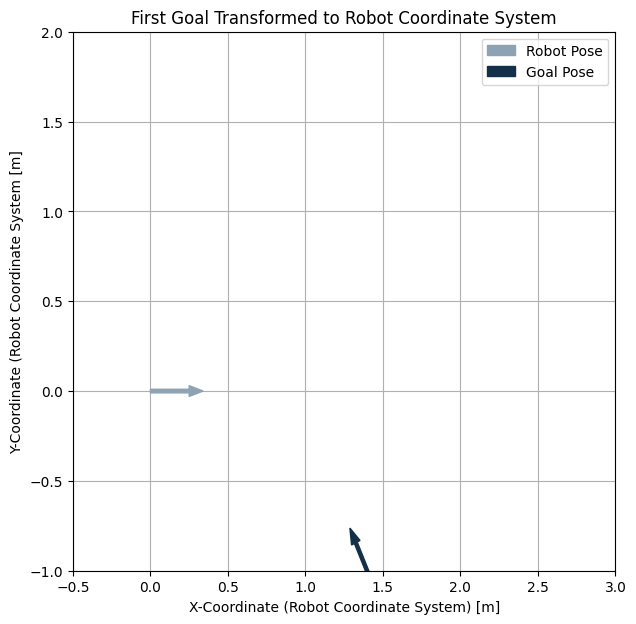

In [8]:
## Visualise transformed goal and robot poses
# Create single figure
plt.rcParams['figure.figsize'] = [7, 7]
fig, ax = plt.subplots()

# Plot robot poses as arrows to indicate orientation
poses = [[0,0,0], goalpose.tolist()]
labels = ["Robot Pose", "Goal Pose"]
colours = [colourScheme["lightblue"], colourScheme["darkblue"]]

for s, l, c in zip(poses, labels, colours):
    # Calculate arrow's dx and dy from s = [x, y, theta]
    p2 = np.array([np.cos(s[2]), np.sin(s[2])])
    # Scale arrow length and draw
    p2 /= np.linalg.norm(p2)*4
    ax.arrow(s[0], s[1], p2[0], p2[1], width=0.02, label=l, color=c)

# Plot walls (from Step 1, if the variable exists)
if 'wallPositions' in locals():
    try: ax.scatter(wallPositions[:,1], wallPositions[:,0], c=colourScheme["darkblue"], alpha=1.0, s=6**2, label="Walls")
    except: pass

# Set axes labels and figure title
ax.set_xlabel("X-Coordinate (Robot Coordinate System) [m]")
ax.set_ylabel("Y-Coordinate (Robot Coordinate System [m]")
ax.set_title("First Goal Transformed to Robot Coordinate System")

# Set grid to only plot each metre
ax.set_xticks = [-1, 0, 1]
ax.set_yticks = [-1, 0, 1]
ax.set_xlim(-0.5, 3)
ax.set_ylim(-1, 2)

# Move grid behind points
ax.set_axisbelow(True)
ax.grid()

# Add labels
ax.legend()

# Show plot
plt.show()

In [9]:
import numpy.typing as npt

def generateControls(lastControl: npt.ArrayLike) -> np.ndarray:
    # 1. v (선속도) 파라미터 설정
    v_min = -0.025
    v_max_val = 0.0325
    v_step = 0.0115
    vt = np.arange(v_min, v_max_val + v_step/2, v_step)

    # 2. w (각속도) 파라미터 설정
    w_min = -1.4
    w_max_val = 1.4
    w_step = 0.025
    wt = np.arange(w_min, w_max_val + w_step/2, w_step)
    
    # 3. 데이터 생성 루프
    controls = np.array([[v, w] for w in wt for v in vt])
    
    return controls

In [10]:
last_control = [0,0]
controls = generateControls(last_control)
print(controls)
print("---")
print(controls.shape)

[[-0.025  -1.4   ]
 [-0.0135 -1.4   ]
 [-0.002  -1.4   ]
 ...
 [ 0.0095  1.4   ]
 [ 0.021   1.4   ]
 [ 0.0325  1.4   ]]
---
(678, 2)


In [11]:
def forwardKinematics(control: npt.ArrayLike, lastPose: npt.ArrayLike, dt: float, dtype=np.float64) -> np.ndarray:
    """Mobile robot forward kinematics (see Thrun Probabilistic Robotics)"""
    
    
    if not isinstance(lastPose, np.ndarray):  # Check input formatting
        lastPose = np.array(lastPose, dtype=dtype)
    assert lastPose.shape == (3,), "Wrong pose format. Pose must be provided as list or array of form [x, y, theta]"
    
    if not isinstance(control, np.ndarray): control = np.array(control)
    assert control.shape == (2,), "Wrong control format. Control must be provided as list or array of form [vt, wt]"
    
    vt, wt = control
    
    # Set omega to smallest possible nonzero value in case it is zero to avoid division by zero
    if wt == 0:
            wt = np.finfo(dtype).tiny
    
    vtwt = vt/wt
    _, _, theta = lastPose
    
    return lastPose + np.array([
        -vtwt*np.sin(theta) + vtwt*np.sin(theta + (wt*dt)),
        vtwt*np.cos(theta) - vtwt*np.cos(theta + (wt*dt)),
        wt*dt
    ], dtype=dtype)

class PT2Block:
    """Discrete PT2 Block approximated using the Tustin approximation (rough robot dynamics model)
    """
    def __init__(self, T=0, D=0, kp=1, ts=0, bufferLength=3) -> None:
        self.k1, self.k2, self.k3, self.k4, self.k5, self.k6 = 0, 0, 0, 0, 0, 0
        self.e = [0 for i in range(bufferLength)]
        self.y = [0 for i in range(bufferLength)]
        if ts != 0:  self.setConstants(T, D, kp, ts)
    #
    def setConstants(self, T, D, kp, ts) -> None:
        self.k1 = 4*T**2 + 4*D*T*ts + ts**2
        self.k2 = 2*ts**2 - 8*T**2
        self.k3 = 4*T**2 - 4*D*T*ts + ts**2
        self.k4 = kp*ts**2
        self.k5 = 2*kp*ts**2
        self.k6 = kp*ts**2
    #
    def update(self, e) -> float:    
        self.e = [e]+self.e[:len(self.e)-1] # Update buffered input and output signals
        self.y = [0]+self.y[:len(self.y)-1]
        e, y = self.e, self.y # Shorten variable names for better readability
        # Calculate output signal and return output
        y[0] = ( e[0]*self.k4 + e[1]*self.k5 + e[2]*self.k6 - y[1]*self.k2 - y[2]*self.k3 )/self.k1
        return y[0]

In [12]:
## Implements costFn function that evaluates control signals

def costFn(pose: npt.ArrayLike, goalpose: npt.ArrayLike, control: npt.ArrayLike) -> float:
    # 1. state error 계산
    e = np.abs(pose - goalpose)
    
    # 회전 오차가 -π ~ π 범위를 벗어나면 보정
    if e[2] > np.pi:
        e[2] = 2*np.pi - e[2]
    
    # 2. control 절댓값
    u = np.abs(control)
    
    # 3. 가중치 행렬 Q, R 정의
    Q = np.array([
        [1,   0,   0  ],
        [0,   1,   0  ],
        [0,   0,   0.5]
    ])
    
    R = np.array([
        [0.1, 0  ],
        [0,   0.1]
    ])
    
    # 4. cost 계산
    cost = e.T @ (Q @ e) + u.T @ (R @ u)
    
    return cost

In [13]:
import copy

def evaluateControls(controls, robotModelPT2, horizon):
    costs = np.zeros_like(np.array(controls)[:,0], dtype=float)
    trajectories = [ [] for _ in controls ]
    
    # Apply range of control signals and compute outcomes
    for ctrl_idx, control in enumerate(controls):
    
        # Copy currently predicted robot state
        forwardSimPT2 = copy.deepcopy(robotModelPT2)
        forwardpose = [0,0,0]
    
        # Simulate until horizon
        for step in range(horizon):
            control_sim = copy.deepcopy(control)
            v_t, w_t = control
            v_t_dynamic = forwardSimPT2.update(v_t)
            control_dym = [v_t_dynamic, w_t]
            forwardpose = forwardKinematics(control_dym, forwardpose, ts)
            costs[ctrl_idx] += costFn(forwardpose, goalpose, control_sim)
            # Track trajectory for visualisation
            trajectories[ctrl_idx].append(forwardpose)

    return costs, trajectories

ts = 1/2 # Sampling time [sec] -> 2Hz
horizon = 5 # Number of time steps to simulate. 10*0.5 sec = 5 seconds lookahead into the future
robotModelPT2 = PT2Block(ts=ts, T=0.05, D=0.8)
costs, trajectories = evaluateControls(controls, robotModelPT2, 70) # -> We sample 70 control updates here to make the visualisation later prettier. This is too slow for actual control

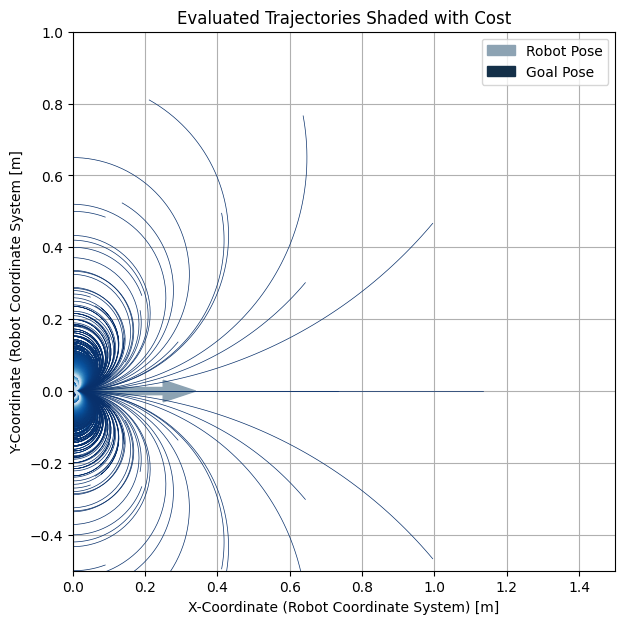

In [14]:
## Visualise transformed goal and robot poses
# Create single figure
plt.rcParams['figure.figsize'] = [7, 7]
fig, ax = plt.subplots()

# Plot robot poses as arrows to indicate orientation
poses = [[0,0,0], goalpose.tolist()]
labels = ["Robot Pose", "Goal Pose"]
colours = [colourScheme["lightblue"], colourScheme["darkblue"]]

for s, l, c in zip(poses, labels, colours):
    # Calculate arrow's dx and dy from s = [x, y, theta]
    p2 = np.array([np.cos(s[2]), np.sin(s[2])])
    # Scale arrow length and draw
    p2 /= np.linalg.norm(p2)*4
    ax.arrow(s[0], s[1], p2[0], p2[1], width=0.02, label=l, color=c)

# Plot walls (from Step 1, if the variable exists)
if 'wallPositions' in locals():
    try: ax.scatter(wallPositions[:,1], wallPositions[:,0], c=colourScheme["darkblue"], alpha=1.0, s=6**2, label="Walls")
    except: pass

import matplotlib.cm as cm

# cost 기반으로 컬러맵 적용
costs_scaled = (costs - costs.min())/(costs.max() - costs.min())
colormap = cm.Blues  # 낮은 cost = 진한 파랑

for traj, cost in zip(trajectories, costs_scaled):
    traj = np.array(traj)
    color = colormap(1 - cost)  # cost 낮을수록 진하게
    ax.plot(traj[:,0], traj[:,1], c=color, linewidth=0.5)

# Set axes labels and figure title
ax.set_xlabel("X-Coordinate (Robot Coordinate System) [m]")
ax.set_ylabel("Y-Coordinate (Robot Coordinate System [m]")
ax.set_title("Evaluated Trajectories Shaded with Cost")

# Set grid to only plot each metre
ax.set_xticks = [-1, 0, 1]
ax.set_yticks = [-1, 0, 1]

ax.set_xlim(-0, 1.5)
ax.set_ylim(-0.5, 1)

# Move grid behind points
ax.set_axisbelow(True)
ax.grid()

# Add labels
ax.legend()

# Show plot
plt.show()

In [15]:
## Finds idx in costs vector and reads the corresponding entry in trajectories and controls
idx = np.argmin(costs)

In [16]:
print(f"Index with lowest cost: {idx}")
print(f"Resulting cost: {costs[idx]}")
print(f"Resulting control: {controls[idx]}")

Index with lowest cost: 361
Resulting cost: 256.20829709191355
Resulting control: [-0.0135  0.1   ]


In [17]:
# Implements publishing of control (cmd_vel), trajectory and the current goal

# 퍼블리셔 생성 (한 번만 실행)
from geometry_msgs.msg import TwistStamped, PoseStamped
from nav_msgs.msg import Path

cmd_vel_pub = node.create_publisher(TwistStamped, '/cmd_vel', 10)
trajectory_pub = node.create_publisher(Path, '/local_planner/trajectory', 10)
goal_pub = node.create_publisher(PoseStamped, '/local_planner/goal', 10)


def pubCMD(control):
    msg = TwistStamped()
    msg.header.stamp = node.get_clock().now().to_msg()
    msg.header.frame_id = "base_link"
    msg.twist.linear.x = float(control[0])   # vt
    msg.twist.angular.z = float(control[1])  # wt
    cmd_vel_pub.publish(msg)

def pubTrajectory(trajectory):
    msg = Path()
    msg.header.stamp = node.get_clock().now().to_msg()
    msg.header.frame_id = "base_link"
    for pose in trajectory:
        p = PoseStamped()
        p.header.frame_id = "base_link"
        p.pose.position.x = float(pose[0])
        p.pose.position.y = float(pose[1])
        msg.poses.append(p)
    trajectory_pub.publish(msg)

def pubGoal(goalpose):
    msg = PoseStamped()
    msg.header.stamp = node.get_clock().now().to_msg()
    msg.header.frame_id = "base_link"
    msg.pose.position.x = float(goalpose[0])
    msg.pose.position.y = float(goalpose[1])
    goal_pub.publish(msg)

In [18]:
pubCMD(controls[idx]) # <- Uncomment to make the robot move
pubTrajectory(trajectories[idx])
pubGoal(goalpose)

In [ ]:
last_control = [0, 0]
current_goal_ID = 0
robotModelPT2 = PT2Block(ts=ts, T=0.05, D=0.8)

while current_goal_ID < len(global_path):
    # 1. 로봇 위치 파악
    robotpose = localiseRobot()
    
    # 2. 현재 목표 선택
    goal = global_path[current_goal_ID]
    
    # 3. 목표를 로봇 기준으로 변환
    T_robot = pose2tf_mat(robotpose)
    T_goal = pose2tf_mat(goal)
    goalpose = tf_mat2pose(np.linalg.inv(T_robot) @ T_goal)
    
    # 4. 제어 신호 생성
    controls = generateControls(last_control)
    
    # 5. 순방향 시뮬레이션
    costs, trajectories = evaluateControls(controls, robotModelPT2, horizon)
    
    # 6. 최적 제어 신호 선택
    idx = np.argmin(costs)
    last_control = controls[idx]
    
    # 7. ROS에 발행
    pubCMD(controls[idx])
    pubTrajectory(trajectories[idx])
    pubGoal(goalpose)
    
    # 목표 도달 확인 (0.3m 이내면 다음 목표로)
    dist = np.sqrt(goalpose[0]**2 + goalpose[1]**2)
    if dist < 0.3:
        print("Goal changed!")
        current_goal_ID += 1

# 로봇 정지
pubCMD([0, 0])
print("Done!")